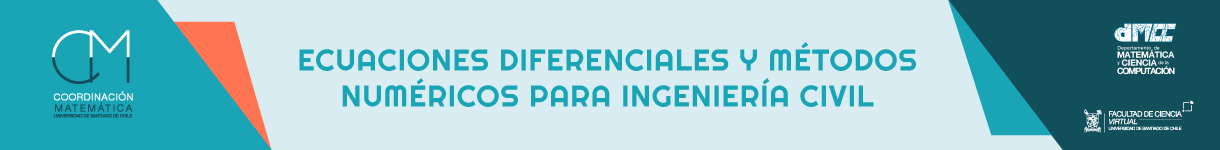

# **Semana 3:**
- Programación de métodos numéricos para la resolución de Ecuaciones Diferenciales Ordinarias.
- Método de Euler y Runge-Kutta.

# Métodos numéricos para EDO's

Cuando trabajamos con métodos numéricos en la resolución de ecuaciones diferenciales, el objetivo es encontrar un conjunto de valores que se aproximen una solución particular de la ecuación diferencial propuesta.

Existen diferentes algoritmos que permiten implementar estos métodos numéricos, algunos más certeros que otros, y por lo tanto, es posible (en ocasiones) estimar el error y decidir qué método emplear en cada etapa de la busqueda de una buena aproximación de la solución.

Consideremos el PVI dado por
$$$$
$$
\begin{cases}
    \frac{dy}{dx}=f(x,y(x)) & ,x\in [a,b] \\
    y(x_0)=y_0
\end{cases}
$$
$$$$
y la partición equiespaciada del intervalo $[a,b]$ en $N$ partes iguales:

$$x_0=a\;< x_1\; x_2< \dots < x_N=b$$
Es decir, usamos los nodos equiespaciados de la forma $x_i=x_0+i\cdot h$ con $h=\frac{b-a}{N}$ y $i=0,1,2,\dots ,N$.

Con esta notación, tenemos los siguientes algoritmos:

$$$$

---
---
# Algortimo 1: Método de Euler

$x_0=a$

$y_0=y_0$

Para $i=0,1,2,\dots ,N-1$

$\quad\quad x_i=x_0 + i\cdot h$

$\quad\quad y_{i+1}=y_i+h\cdot f(x_i,y_i)$

Fin $i$

---
# Algoritmo 2: Método de Euler mejorado - Heun - Runge-Kutta de orden 2

$x_0=a$

$y_0=y_0$

Para $i=0,1,2,\dots ,N-1$

$\quad\quad x_i=x_0 + i\cdot h$

$\quad\quad x_{i1}=x_i + h$

$\quad\quad y_{y1}=y_i +h\cdot f(x_i,y_i)$

$\quad\quad y_{i+1}=y_i+\frac{h}{2}\left[f(x_i,y_i)+f(x_{i1},y_{i1})\right]$

Fin $i$

---
# Algoritmo 3: Método de Runge-Kutta de orden 4

$x_0=a$

$y_0=y_0$

Para $i=0,1,2,\dots ,N-1$

$\quad\quad x_i = x_0+ih $

$\quad\quad K_1 = h f(x_i,y_i) $

$\quad\quad K_2 = h f\left( x_i + \dfrac{h}{2} , y_i + \dfrac{1}{2} K_1 \right) $

$\quad\quad K_3 = h f\left( x_i + \dfrac{h}{2} , y_i + \dfrac{1}{2} K_2 \right) $

$\quad\quad K_4 = h f\left( x_i + h , y_i + K_3 \right) $

$\quad\quad y_{i+1} = y_i + \dfrac{1}{6} \left[ K_1 + 2K_2 + 2K_3 + K_4 \right] $

Fin $i$

---
---

$$$$

#Funciones en Python

Para trabajar con estos métodos, debemos definir una función en Python, llamada `Euler`, `Euler2` y `RK4` que permitan encontrar una aproximación para $y(x_n)$ utilizando el respectivo método.


Una función en Python es un bloque de código reutilizable que realiza una acción específica. De manera general, una función se define siguiendo la estructura mostrada a continuación:
```
def nombre_fun(arg1, arg2, ...., argn):
    #cuerpo de la función
    return val1, val2, ..., valn
```

En nuestro caso utilizamos un nombre que indique el método que usaremos y establecemos que los parámetros de entrada: $f(x,y), x_0, x_N, y_0, N$.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

## Método de Euler

In [2]:
def Euler(f,x0,xn,y0,n):              #Nuestra función se llama Euler y sus datos de entrada son f,x0,xn,y0,n
    X = np.linspace(x0,xn,n+1)        #Recordemos que para tener n segmentos necesitamos n+1 puntos
    Y = np.empty(n + 1)               #Crea una lista "vacía" de longitud n
    Y[0] = y0
    h=(xn-x0)/n
    for i in range(n):                #Recordemos que el método se ejecuta para i=0,1,2,...,n-1
        Y[i+1] = Y[i] + h*f(X[i],Y[i])
    return Y

## Método de Euler mejorado - Heun - Rk2

In [ ]:
def RK22(f, x0, xn, y0, n):
    X = np.linspace(x0, xn,n+1) # Arreglo de puntos en el intervalo [x0, xn] con n segmentos
    Y = np.empty(n + 1)         # Arreglo para almacenar los valores de y correspondientes a cada punto en X con n segmentos
    Y[0] = y0                   # Y[0] se inicializa con el valor inicial y0
    h = (xn - x0) / n           # Definimos el paso h como la cantidad que se avanza en cada iteración, calculada como la longitud del intervalo dividido por el número de segmentos
    for i in range(n):
        k1 = f(X[i], Y[i])                      # k1 = f(x0 + i*h, y_i)
        k2 = f(X[i] + h, Y[i] + h * k1)         # k2 = f(x0 + (i+1)*h, y_i + h*k1)
        Y[i + 1] = Y[i] + (h / 2) * (k1 + k2)   # y_i+1 = y_i + (h/2)*(k1 + k2)
    return Y    # Devuelve el arreglo Y con los n segmentos calculados, Y[n] es la aproximación de y(xn) usando el método RK22

#Método de Runge-Kutta de orden 4

In [ ]:
def RK4(f, x0, xn, y0, n):
    X = np.linspace(x0,xn,n+1)
    Y = np.empty(n + 1)
    Y[0] = y0
    h = (xn-x0)/n
    for i in range(n):
        K1=h*f(X[i],Y[i])
        K2=h*f(X[i]+h/2,Y[i]+(1/2)*K1)
        K3=h*f(X[i]+h/2,Y[i]+(1/2)*K2)
        K4=h*f(X[i]+h,Y[i]+K3)
        Y[i+1] = Y[i] +(1/6)*(K1+2*K2+2*K3+K4)
    return Y

### Ejemplo

Considere el siguiente PVI, visto en clases:

$$ y'=y \quad ; \quad y(0)=1$$

- a) Encuentre su solución.
- b) Use dicha solución, para encontrar una aproximación de $e$.

### a) Buscamos su solución usando Python:

In [3]:
#Importación de librerías
import numpy as np
import sympy as sp
from sympy import *
sp.init_printing(use_latex='mathjax')

# Se definen las variables
x = sp.Symbol('x', real=True)
y = sp.Function('y')

# Expresamos la ecuación diferencial
f = y(x)
sp.Eq(y(x).diff(x), f)

d              
──(y(x)) = y(x)
dx             

In [4]:
#Resolvemos el PVI con dsolve:
sp.dsolve(y(x).diff(x) - f, ics={y(0):1})

        x
y(x) = ℯ 

La solución de la ecuación diferencial es $y(x)=e^x$.

- b) Para encontrar una aproximación de $e$, basta considerar $x=1$ y tendremos:

$y(1)=e$.
Así, entonces usaremos el método de Euler para encontrar una aproximación, usando la función solución del PVI:

In [15]:
def f(x,y):                   #Lo que hace f de la ecuación diferencial dy/dx=f(x,y) es justamente dar "y". Como f(x,y)=y retornamos "y"
  return y

display(Euler(f, 0, 1, 1, 20))            #Llamamos a la función que aplica el método con Euler(f,x0,xn,y0,n) y sabemos que y0=y(a=x0=0)=1 y xn=b=1.
display(Euler(f, 0, 1, 1, 20)[-1])        #Solo nos quedamos con el último valor de la lista

array([1.        , 1.05      , 1.1025    , 1.157625  , 1.21550625,
       1.27628156, 1.34009564, 1.40710042, 1.47745544, 1.55132822,
       1.62889463, 1.71033936, 1.79585633, 1.88564914, 1.9799316 ,
       2.07892818, 2.18287459, 2.29201832, 2.40661923, 2.5269502 ,
       2.65329771])

np.float64(2.6532977051444213)

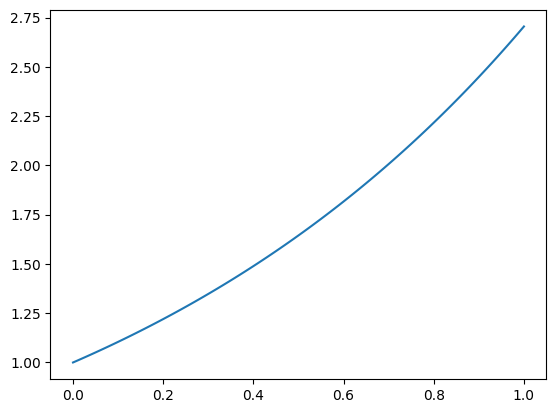

In [23]:
t = np.linspace(0,1,101)
y_t = Euler(f, 0, 1, 1, 100)
plt.plot(t, y_t, label='Euler')

Lo que hemos obtenido es una aproximación, dada por:

$$y(1)\approx 2.65329771.$$

Podemos calcular el error absoluto obtenido en la aproximación,

In [25]:
error_euler=np.abs(np.exp(1)-Euler(f, 0,1,1,20)[-1])          #Error_euler y [-1] indica el último elemento de la lista
display(error_euler)

np.float64(0.06498412331462378)

Lo que corresponde a un error absoluto de 0.065 aproximadamente.

#### ¿Y con Runge-Kutta de orden 4?

Usemos RK4 para aproximar $e$.

In [31]:
display(RK4(f, 0, 1, 1, 20))
display(RK4(f, 0, 1, 1, 20)[-1])

array([1.        , 1.05127109, 1.10517091, 1.16183423, 1.22140275,
       1.2840254 , 1.34985879, 1.41906752, 1.49182467, 1.56831215,
       1.64872123, 1.73325297, 1.82211875, 1.91554077, 2.01375264,
       2.11699994, 2.22554084, 2.33964675, 2.459603  , 2.58570954,
       2.71828169])

np.float64(2.718281692656335)

y calculamos su error:

In [30]:
error_rk4=np.abs(np.exp(1)-RK4(f, 0,1,1,20)[-1])       #error_rk4
error_rk4

np.float64(1.3580270996627064e-07)

Si queremos que el resultado se muestre con más valores después de la coma, hacemos:

In [33]:
print('El error mediante el método RK4 es: {:,.15f}'.format(error_rk4))            #El 15 indica la cantidad de decimales

El error mediante el método RK4 es: 0.000000135802710


Claramente, el método RK44 entrega una solución una mejor aproximación.
$$$$

**Para investigar:**

¿Cuáles son los órdenes de convergencia de cada método? ¿Existe una cota superior que permita controlar el error?

# Ejercicios
Primero definir:

In [40]:
import numpy as np
import sympy as sp

def Euler(f,x0,xn,y0,n):              #Nuestra función se llama Euler y sus datos de entrada son f,x0,xn,y0,n
    X = np.linspace(x0,xn,n+1)        #Recordemos que para tener n segmentos necesitamos n+1 puntos
    Y = np.empty(n + 1)               #Crea una lista "vacía" de longitud n
    Y[0] = y0
    h=(xn-x0)/n
    for i in range(n):                #Recordemos que el método se ejecuta para i=0,1,2,...,n-1
        Y[i+1] = Y[i] + h*f(X[i],Y[i])
    return Y

def RK2(f, x0, xn, y0, n):
    X = np.linspace(x0, xn,n+1) # Arreglo de puntos en el intervalo [x0, xn] con n segmentos
    Y = np.empty(n + 1)         # Arreglo para almacenar los valores de y correspondientes a cada punto en X con n segmentos
    Y[0] = y0                   # Y[0] se inicializa con el valor inicial y0
    h = (xn - x0) / n           # Definimos el paso h como la cantidad que se avanza en cada iteración, calculada como la longitud del intervalo dividido por el número de segmentos
    for i in range(n):
        k1 = f(X[i], Y[i])                      # k1 = f(x0 + i*h, y_i)
        k2 = f(X[i] + h, Y[i] + h * k1)         # k2 = f(x0 + (i+1)*h, y_i + h*k1)
        Y[i + 1] = Y[i] + (h / 2) * (k1 + k2)   # y_i+1 = y_i + (h/2)*(k1 + k2)
    return Y    # Devuelve el arreglo Y con los n segmentos calculados, Y[n] es la aproximación de y(xn) usando el método RK2

def RK4(f, x0, xn, y0, n):
    X = np.linspace(x0,xn,n+1)
    Y = np.empty(n + 1)
    Y[0] = y0
    h = (xn-x0)/n
    for i in range(n):
        K1=h*f(X[i],Y[i])
        K2=h*f(X[i]+h/2,Y[i]+(1/2)*K1)
        K3=h*f(X[i]+h/2,Y[i]+(1/2)*K2)
        K4=h*f(X[i]+h,Y[i]+K3)
        Y[i+1] = Y[i] +(1/6)*(K1+2*K2+2*K3+K4)
    return Y

# Ejercicio 1

Considere el problema de valores iniciales
$$ y'=\dfrac{y}{x}+x\mathrm{e}^{-\frac{y}{x}} \quad ; \quad y(1)=2$$
- a) Utilice el método de Euler para encontrar una aproximación de $y(11)$ para el problema de valores iniciales utilizando $h=0.25,h=0.5$ y $h=1$.

- b) Encuentre la solución del PVI realizando la sustitución $y=zx$ o use `dsolve`.

- c) En un mismo gráfico trace la solución aproximada y la solución explícita al PVI.

- d) Calcule el error absoluto para cada $h$ utilizado, luego justifique si es una buena aproximación ¿Cómo podría mejorar esta aproximación?

- e) Usando Rk44 compare sus resultados utilizando los mismos valores de $h$.

#### <span style = "color:#8fc5ff"> Solución </span>
* a) Definimos $n$ como la cantidad de pasos para ir desde $x = 1 \rightarrow x = 11$
$$ h=0.25, n=40$$
$$ h=0.5, n=20$$
$$ h=1, n=10$$

In [79]:
def f(x,y):                   #f es la ecuacion diferencial dy/dx=y/x + x*np.exp(-y*x)
  return y/x + x*np.exp(-y/x)

x0 = 1
xn = 11
y0 = 2
print(f"y(11) con h=1: {Euler(f, x0, xn, y0, 10)[-1]}")
print(f"y(11) con h=0.5: {Euler(f, x0, xn, y0, 20)[-1]}")
print(f"y(11) con h=0.25: {Euler(f, x0, xn, y0, 40)[-1]}")

y(11) con h=1: 30.273285998556908
y(11) con h=0.5: 30.818789335644183
y(11) con h=0.25: 31.109727162557597


* b) Solucionar la ecuacion diferencial usando la sustitucion $z = \frac{y}{x}$

In [82]:
x = sp.Symbol('x', real=True)
y = sp.Function('y')

f = y(x)/x + x*sp.exp(-y(x)*x)

#z = y/x
#zx = y --> (dz/dx)x + z = dy/dx

z = sp.Function('z')(x)

g = sp.Eq(z + x*sp.exp(-z), z.diff(x)*x + z)
g = sp.dsolve(g, z)

g = g.subs(z, y(x)/x)
g = sp.simplify(g)

C1 = sp.Symbol('C1')
eq_C = g.subs(x, 1).subs(y(1), 2)
C1_value = sp.solve(eq_C, C1)[0]
g = g.subs(C1, C1_value)
g = sp.simplify(g)
g = sp.solve(g, y(x))[0]
display(g)
g.subs(x, 11)
g = sp.lambdify(x, g, 'numpy')
print(f"y(11) con la solución numerica: {g(11)}")

     ⎛         2⎞
x⋅log⎝x - 1 + ℯ ⎠

y(11) con la solución numerica: 31.41425153361771


* c) Graficar $y(x)$ y la aproximacion:

In [83]:
x = np.linspace(x0, xn, 41)

Y1 = Euler(f, x0, xn, y0, 40)
Y2 = Euler(f, x0, xn, y0, 20)
Y3 = Euler(f, x0, xn, y0, 10)
Y = x*np.exp(x - 1 + np.exp(2))

plt.plot(np.linspace(x0, xn, 41), Y1, label='h=0.25')
plt.plot(np.linspace(x0, xn, 21), Y2, label='h=0.5')
plt.plot(np.linspace(x0, xn, 11), Y3, label='h=1')
plt.plot(x, Y, label='Solución exacta')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

TypeError: 'Add' object is not callable

# Ejercicio 2

La EDO autónoma y de Riccati

$$m \frac{dy}{dt} = mg − ky^2$$

modela la velocidad $y(t)$ de un cuerpo de masa $m$ (en kg) que está cayendo bajo la influencia de la gravedad. Debido a que el término $–ky^2$ representa la resistencia del aire, la velocidad de un cuerpo que cae de una gran altura no aumenta sin límite conforme pasa el tiempo $t$.

Suponga que el cuerpo tiene masa $2 \;[kg]$ y $k = 2$ donde $g = 9, 8 \left[ \frac{m}{s^2} \right]$ y que en el instante $t=0$ el cuerpo tiene velociadad $10 \left[ \frac{m}{s} \right]$.

- a) Usando el método de Euler, determine la velocidad del cuerpo al cabo de $10 [s]$, usando:
    * $h=0.1$
    * $n=300$

- b) Verifique que $y(t) = \dfrac{\sqrt{g} \sqrt{m} }{\sqrt{k}} \tanh\left[ \sqrt{g} \sqrt{k}\left( C \sqrt{m}+ \dfrac{t}{\sqrt{m}} \right) \right]$ es la solución general de la EDO.
- c) Calcule la solución particular que satisface la condición inicial.
- d) Calcule el error cometido en cada uno de las aproximaciones de a). Justifique cuál es una mejor aproximación.

#Ejercicio 3

Considere el siguiente PVI:

$$ y' = 0,2xy \quad ; \quad y(0) = 1.$$

* a) Utilice el método RK4 para encontrar una aproximación de $y(4)$ donde $h=1$.
* b) Usando Python resuelva la ecuación y determine si es una buena aproximación (haga un análisis del error obtenido).

# Ejercicio 4

La ecuación
$$\frac{dP}{dt}=kP\left(1-\frac{P}{N} \right)-a$$
representa un modelo logístico de crecimiento poblacional con cosecha constante.

Para una cierta variedad de pez comestible, se considera $a=0.5$, $k=3$ y $N=10$, donde $N$ y $P(t)$ están medidas en miles.

Suponga que en el instante $t=0$ (medido en días) la población inicial de peces es $2600$.

* a) Use el método RK4 para estimar la población de peces al cabo de una semana.

* b) Estime la cantidad de peces diarios al cabo de un año completo. ¿La población de peces se estabiliza después de cierto tiempo? ¿Qué se espera de $P(t)$ si $t \to \infty$?

* c) La EDO resultante es autónoma. Utilice técnicas cualitativas para corroborar los resultados anteriores.

* d) Resuelva la EDO vía separación de variables, luego calcule la población al cabo de un año. Compruebe si sus resultados coinciden con los obtenidos anteriormente.